In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import splitfolders
import albumentations as A
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
import math
import time
import requests
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import glob

In [ ]:
BASE_DIR = r"Klasifikasi Kutu\Input2"
TARGET_PER_SPECIES = 500
THREADS = 15

API_URL = "https://api.inaturalist.org/v1/observations"

species_list = [
    "Dermacentor variabilis",
    "Ixodes scapularis",
    "Rhipicephalus sanguineus"
]


def validate_image(img_bytes):
    try:
        img = Image.open(BytesIO(img_bytes))
        img.verify()
        return True
    except:
        return False


def download_one(url, save_path):
    for _ in range(3):  # retry 3x
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200 and validate_image(r.content):
                with open(save_path, "wb") as f:
                    f.write(r.content)
                return True
        except:
            time.sleep(1)
    return False


def scrape_species(species):
    print(f"\n=== SCRAPING: {species} ===")

    folder = os.path.join(BASE_DIR, species)
    os.makedirs(folder, exist_ok=True)

    collected_urls = []

    # == 1. Ambil total data dulu ==
    params = {
        "taxon_name": species,
        "photos": True,
        "per_page": 1,
    }
    resp = requests.get(API_URL, params=params).json()
    total_results = resp.get("total_results", 0)
    if total_results == 0:
        print("[ERROR] Tidak ada data!")
        return
    
    per_page = 200  # MAX
    total_pages = math.ceil(total_results / per_page)

    print(f"[INFO] Total hasil: {total_results}, Total halaman: {total_pages}")

    # == 2. Loop semua halaman untuk kumpulkan URL ==
    for page in range(1, total_pages + 1):
        params = {
            "taxon_name": species,
            "photos": True,
            "page": page,
            "per_page": per_page,
        }

        data = requests.get(API_URL, params=params).json().get("results", [])

        for obs in data:
            if not obs.get("photos"):
                continue
            url = obs["photos"][0]["url"].replace("square", "large")
            collected_urls.append(url)

        if len(collected_urls) >= TARGET_PER_SPECIES:
            break

    print(f"[INFO] Total URL terkumpul: {len(collected_urls)}")

    # == 3. Download dengan multithread ==
    tasks = []
    with ThreadPoolExecutor(max_workers=THREADS) as exe:
        for i, url in enumerate(collected_urls[:TARGET_PER_SPECIES]):
            ext = url.split(".")[-1].lower()
            if ext not in ["jpg", "jpeg", "png"]:
                ext = "jpg"
            save_path = os.path.join(folder, f"{i+1}.{ext}")
            tasks.append(exe.submit(download_one, url, save_path))

        for _ in tqdm(tasks, desc=f"Mengunduh {species}"):
            _.result()

    print(f"[DONE] Gambar tersimpan: {min(TARGET_PER_SPECIES, len(collected_urls))}")
for sp in species_list:
    scrape_species(sp)


=== SCRAPING: Dermacentor variabilis ===
[INFO] Total hasil: 26122, Total halaman: 131
[INFO] Total URL terkumpul: 599


Mengunduh Dermacentor variabilis: 100%|██████████| 500/500 [01:00<00:00,  8.32it/s]


[DONE] Gambar tersimpan: 500

=== SCRAPING: Ixodes scapularis ===
[INFO] Total hasil: 14483, Total halaman: 73
[INFO] Total URL terkumpul: 596


Mengunduh Ixodes scapularis: 100%|██████████| 500/500 [01:04<00:00,  7.70it/s]


[DONE] Gambar tersimpan: 500

=== SCRAPING: Rhipicephalus sanguineus ===
[INFO] Total hasil: 2571, Total halaman: 13
[INFO] Total URL terkumpul: 594


Mengunduh Rhipicephalus sanguineus: 100%|██████████| 500/500 [01:01<00:00,  8.16it/s]


[DONE] Gambar tersimpan: 500

=== SCRAPING: Ctenocephalides canis ===
[INFO] Total hasil: 82, Total halaman: 1
[INFO] Total URL terkumpul: 79


Mengunduh Ctenocephalides canis: 100%|██████████| 79/79 [00:08<00:00,  9.30it/s]

[DONE] Gambar tersimpan: 79


In [ ]:
base_folder = r"Klasifikasi Kutu\Input"

# ekstensi gambar
extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.gif"]

# loop setiap subfolder
for subfolder in os.listdir(base_folder):
    folder_path = os.path.join(base_folder, subfolder)

    if os.path.isdir(folder_path):
        images = []
        for ext in extensions:
            images.extend(glob.glob(os.path.join(folder_path, ext)))

        print(f"{subfolder}: {len(images)} gambar")


Dermacentor variabilis: 200 gambar
Ixodes scapularis: 200 gambar
Rhipicephalus sanguineus: 200 gambar


# Resize Gambar

In [5]:
input_folder = 'Input'      
size = (256, 256)                  

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(nama_kelas, filename)
                img = Image.open(img_path)
                img_resized = img.resize(size)
                img_resized.save(os.path.join(nama_kelas, filename))

# Preprocessing

In [6]:
os.makedirs('Datasplit', exist_ok=True)
dataraw = './Input'
datasplit = './Datasplit'

In [7]:
splitfolders.ratio(dataraw, output=datasplit, seed=42, ratio=(.6,.2,.2), group_prefix=None)

Copying files: 600 files [00:00, 1262.93 files/s]


In [21]:
# Declare an augmentation pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=0,
        p=0.5
    ),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2)
])

# Read an image with OpenCV and convert it to the RGB colorspace
input_folder = 'Datasplit/train'

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(nama_kelas, filename)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Augment an image
                for i in range(5):
                    transformed = transform(image=image)
                    transformed_image = transformed["image"]
                    augmented_img = Image.fromarray(transformed_image)
                    base, ext = os.path.splitext(filename)
                    augmented_img.save(os.path.join(nama_kelas, f"{base}_augmented_{i+1}{ext}"))

c:\Users\ASUS\anaconda3\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [20]:
input_folder = 'Datasplit/train'

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if "_augmented_" in filename:
                file_path = os.path.join(nama_kelas, filename)
                try:
                    os.remove(file_path)
                    print(f"Deleted: {file_path}")
                except Exception as e:
                    print(f"Failed to delete {file_path}: {e}")

Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_1.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_2.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_3.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_4.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_5.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_1.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_2.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_3.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_4.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_5.jpg
Deleted: Datasplit/train\Dermacentor variabilis\102 (2)_augmented_1.jpg
Deleted: Datasplit/train\Dermacentor variabilis\102 (2)_augmented_2.jpg
Deleted: Datasplit/train\Dermacentor variabilis\102 (2)_augmented_3.jpg
Deleted: Datasplit/train\Dermacentor variabilis\102 (2)_augmented_4.jpg
Deleted: Dat

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import class_weight
import numpy as np

img_size = (256, 256)
batch_size = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/val",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)


AUTOTUNE = tf.data.AUTOTUNE

def normalize(ds):
    return ds.map(
        lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
        num_parallel_calls=AUTOTUNE
    ).cache().prefetch(AUTOTUNE)

train_ds = normalize(train_ds_raw)
val_ds   = normalize(val_ds_raw)
test_ds  = normalize(test_ds_raw)


y_train = np.concatenate([y for _, y in train_ds_raw])
class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

for layer in base_model.layers[:-20]:
    layer.trainable = False
inputs = layers.Input(shape=(256, 256, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Found 4350 files belonging to 3 classes.
Found 321 files belonging to 3 classes.
Found 321 files belonging to 3 classes.
Classes: ['Dermacentor variabilis', 'Ixodes scapularis', 'Rhipicephalus sanguineus']
Class Weights: {0: np.float64(1.0027662517289073), 1: np.float64(1.0111576011157601), 2: np.float64(0.9863945578231292)}
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 521ms/step - accuracy: 0.3736 - loss: 1.1375 - val_accuracy: 0.4019 - val_loss: 1.0858 - learning_rate: 1.0000e-05
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 73s 534ms/step - accuracy: 0.4467 - loss: 1.0731 - val_accuracy: 0.4611 - val_loss: 1.0401 - learning_rate: 1.0000e-05
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 75s 554ms/step - accuracy: 0.4828 - loss: 1.0251 - val_accuracy: 0.5016 - val_loss: 1.0005 - learning_rate: 1.0000e-05
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 71s 520ms/step - accuracy: 0.5244 - loss: 0.9775 - val_accuracy: 0.5421 - val_loss: 0.9620 - learning_rate: 1.0000e-05
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━

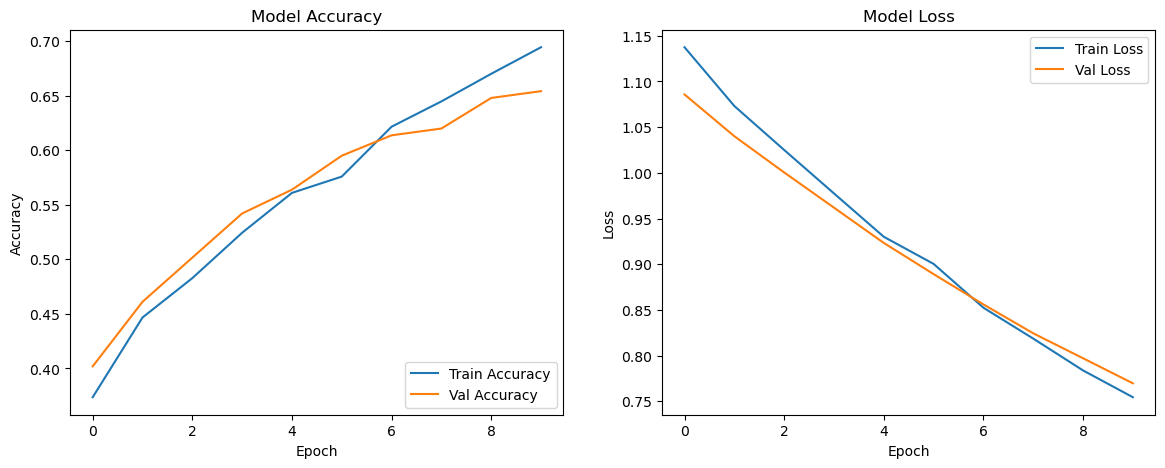

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Classification Report:

                          precision    recall  f1-score   support

  Dermacentor variabilis       0.63      0.65      0.64       109
       Ixodes scapularis       0.70      0.75      0.72       107
Rhipicephalus sanguineus       0.62      0.55      0.58       105

                accuracy                           0.65       321
               macro avg       0.65      0.65      0.65       321
            weighted avg       0.65      0.65      0.65       321



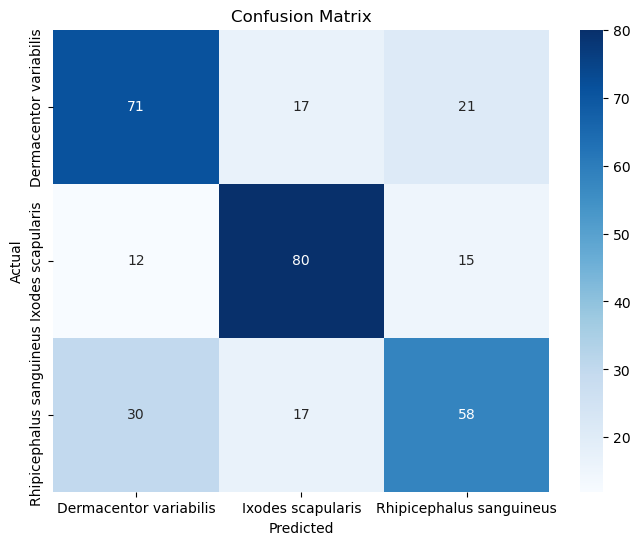

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ========================
# 1. Learning Curve
# ========================
def plot_learning_curve(history):
    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

# ========================
# 2. Classification Report & Confusion Matrix
# ========================
def evaluate_model(model, test_ds_raw, class_names):
    y_true = []
    y_pred = []

    # Loop manual supaya dapat label
    for images, labels in test_ds_raw:  # pakai raw biar urutan tidak shuffle
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

# ========================
# 3. Panggil fungsi
# ========================
plot_learning_curve(history)
evaluate_model(model, test_ds_raw, class_names)
